In [1]:
import warnings
from typing import List, Literal, Optional, Tuple

import moscot as mt
import moscot.plotting as mtp
import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt
import pycea as py

import scanpy as sc
from anndata import AnnData
import treedata as td
from fastrna.core import fastrna_hvg, fastrna_pca

from Moslin.utility import matrixfy_character_obsm

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [2]:
%load_ext autoreload
%autoreload 2



Early run, only **first replicate** is used. Since there are also multiple clones in the replicate, I will take the clone with the biggest lineage tree and as a result should probably subset the data before we concat. 
TODO: Figure out why there are multiple clones. Why the nodes in the tree and the clone cell count do not match up 
TODO: Create cost matrix for each time point, and the cost matrix 
TODO: Use Gene Expression for cost matrix across time points 

### Data loading and Merging


In [2]:
from pathlib import Path
basePath = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_data = basePath + "output_data/"
output_plot = basePath + "output_plot/"

In [30]:
Lineage_data = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")
tdatas = {}
for file_path in Lineage_data.glob("*R1.h5td"): # Taking only the first replicate

    #tdatas[file_path.stem] = td.read_h5td(file_path)

    # For testing, extract only timepoint lower than E9.0
    # Extract stage from filename (e.g., "E8.5-R1" from "E8.5-R1-C1.h5td")
    stem = file_path.stem
    stage = stem.split("-")[0]  # Extract "E8.5", "E9.0", etc.
    
    # Parse the stage to compare versions (e.g., E8.5, E9.0)
    stage_num = float(stage[1:])  # Remove 'E' and convert to float
    
    # Exclude E8.5 and above
    if stage_num < 8.5:
        tdatas[stem] = td.read_h5td(file_path)

In [4]:
tdatas = {}
for tdata_path in Path(output_data+"Processed_data/").glob("*"):
    tdatas[tdata_path.stem] = td.read_h5td(tdata_path)

In [5]:
tdatas.values()

dict_values([TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'leiden_0.25', 'leiden_0.25_colors', 'leiden_0.5', 'leiden_0.5_colors', 'leiden_1.0', 'leiden_1.0_colors', 'leiden_2.0', 'leiden_2.0_colors', 'leiden_names', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', 'characters'
    varm: 'PCs'
    layers: 'Norm_count', 'Raw_count'
    obsp: 'connectivities', 'distances'
    obst: 'E8.5-R3-C1', 'E8.5-R2-C1', 'E8.5-R2-C2', 'E8.5-R1-C1', 'E8.5-R1-C3', 'E8.5-R1-C2', 'E8.5-R3-C3', 'E8.5-R3-C2', 'E8.5-R1-C4', TreeData object with n_obs × n_vars = 21942 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'det

#### Concat Different Days into one adata (All replicate, all clones, all days)


In [6]:
merged_tdata = td.concat(tdatas, merge='unique')

In [7]:
import gc
del tdatas # Free up memory
gc.collect()

49918

In [8]:
merged_tdata

TreeData object with n_obs × n_vars = 115820 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', 'characters'
    layers: 'Norm_count', 'Raw_count'
    obst: 'E8.0-R1-C3', 'E8.5-R3-C3', 'E7.5-R1-C2', 'E7.5-R1-C1', 'E8.0-R2-C2', 'E8.5-R1-C2', 'E8.5-R3-C1', 'E8.5-R3-C2', 'E8.5-R1-C4', 'E7.5-R3-C3', 'E8.0-R3-C2', 'E8.0-R3-C1', 'E8.0-R1-C2', 'E8.0-R3-C5', 'E7.5-R2-C5', 'E7.5-R2-C6', 'E7.5-R2-C1', 'E8.0-R2-C1', 'E7.5-R2-C2', 'E7.5-R3-C1', 'E7.5-R2-C4', 'E8.5-R2-C1', 'E8.5-R2-C2', 'E8.0-R3-C4', 'E8.0-R3-C6', 'E7.5-R3-C2', 'E7.5-R2-C3', 'E8.5-R1-C3', 'E8.0-R3-C3', 'E8.5-R1-C1', 'E8.0-R1-C1'

In [9]:
for obs in merged_tdata.obs:
    print("------------"+obs+"--------")
    print("---------------------------")
    print(set(merged_tdata.obs[obs])) 
    print("---------------------------")

# Note, "stage" obs contain time point

------------cell_subtype--------
---------------------------
{'Spinal cord', 'Allantoic endothelial progenitor', 'Surface ectoderm (anterior)', 'Primitive streak', 'Gut', 'Hematoendothelial progenitor', 'Second heart field (posterior)', 'Notochord', 'Extraembryonic mesoderm', 'Primordial germ cell', 'Extraembryonic ectoderm', 'Nascent mesoderm', 'Lateral plate mesoderm', 'Visceral endoderm', 'Hindbrain', 'Allantois', 'Juxtacardiac field', 'Rostral ectoderm', 'Endothelial progenitor', 'Second heart field (anterior)', 'Anterior mesoderm', 'Intermediate mesoderm', 'First heart field', 'Epiblast', 'Axial progenitor', 'Presomitic mesoderm', 'Nascent somite', 'Surface ectoderm (posterior)', 'Forebrain', 'Definitive endoderm'}
---------------------------
------------capture--------
---------------------------
{'E7.5-R1-T1', 'E8.0-R1-T1'}
---------------------------
------------embryo--------
---------------------------
{'E7.5-R1', 'E8.0-R1'}
---------------------------
------------stage------

### Normalize and PCA (Using fastRNA)

In [ ]:
# Saving raw gene expression as a layer  (Run if not ran before)
#merged_tdata.layers['Raw_count'] = merged_tdata.X.copy()


In [12]:
merged_tdata.X = merged_tdata.layers["Raw_count"] # Make sure to set to raw

In [13]:
gene_exp = merged_tdata.X
gene_exp.max()

np.float32(11486.0)

In [14]:
type(gene_exp)

scipy.sparse._csr.csr_matrix

#### Setting up matrix for fastRNA hvg and pca (Should convert this to a function when matured)

In [15]:
# Creating an Array labeling the batches each cell come from. (Batch is per embryo here)
batch_label = pd.factorize(merged_tdata.obs["embryo"])[0]
batch_label

array([0, 0, 0, ..., 8, 8, 8], shape=(115820,))

Need to sort the matrix before passing it into function

In [16]:
idx_sort = batch_label.argsort() # Create an array of index of each cells that will sorts the batch_label 
batch_label_sort = batch_label[idx_sort] # Sort the batch label 
gene_exp_sort = gene_exp[idx_sort,:].T   # Sort the gene_exp so each cell lines up with the batch label. Transposing to make gene * cell

#### Running fastRNA

Highly variable genes

In [17]:
gene_vars = fastrna_hvg(gene_exp_sort, batch_label_sort) # Passing in gene and batch to generate hvg
gene_idx_var = gene_vars.argsort()[::-1] # Take the gene index
gene_exp_hvg = gene_exp_sort[gene_idx_var[:3000], :]   # Filter for top 3000 HVGs
gene_exp_hvg.sort_indices() # Required for pca 

PCA

In [18]:
numi = np.asarray(gene_exp_sort.sum(axis=0)).ravel()   # size factors (total UMI per cell)
eig_val, eig_vec, pca, rrt = fastrna_pca(gene_exp_hvg, numi, batch_label_sort)

#### Saving Results back into adata

In [19]:
# Storing pca
idx_unsort = np.argsort(idx_sort) # Need to undo sorting from earlier
merged_tdata
merged_tdata.obsm["X_pca_fastRNA"] = pca[idx_unsort, :]

# Store variance explained (eigenvalues) — scanpy expects ratio and ratio_cumsum
total_variance = eig_val.sum()
merged_tdata.uns["pca_fastRNA"] = {
    "variance": eig_val,
    "variance_ratio": eig_val / total_variance,
}

# Store gene loadings (eigenvectors) — shape should be (n_genes, n_pcs)
# eig_vec columns correspond to PCs, rows correspond to the selected HVGs
# Need to map back to full gene space
loadings_full = np.zeros((merged_tdata.n_vars, eig_vec.shape[1]))
loadings_full[gene_idx_var[:3000], :] = eig_vec
merged_tdata.varm["PCs_fastRNA"] = loadings_full

In [20]:
merged_tdata

TreeData object with n_obs × n_vars = 115820 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'pca_fastRNA'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', 'characters', 'X_pca_fastRNA'
    varm: 'PCs_fastRNA'
    layers: 'Norm_count', 'Raw_count'
    obst: 'E8.0-R1-C3', 'E8.5-R3-C3', 'E7.5-R1-C2', 'E7.5-R1-C1', 'E8.0-R2-C2', 'E8.5-R1-C2', 'E8.5-R3-C1', 'E8.5-R3-C2', 'E8.5-R1-C4', 'E7.5-R3-C3', 'E8.0-R3-C2', 'E8.0-R3-C1', 'E8.0-R1-C2', 'E8.0-R3-C5', 'E7.5-R2-C5', 'E7.5-R2-C6', 'E7.5-R2-C1', 'E8.0-R2-C1', 'E7.5-R2-C2', 'E7.5-R3-C1', 'E7.5-R2-C4', 'E8.5-R2-C1', 'E8.5-R2-C2', 'E8.0-R3-C4', 'E8.0-R3-C6', 'E7.5-R3-C2', 'E7.5-R2-C3', 'E8.5-R1-C3', 'E8.0-R3-C3', 'E8.5-R1-C1', 'E8.0-R1-C1'

### Barcode/character Matrix preprocessing

#### Character matrix need to be only numerical values. 

In [21]:
# Check what kind of characters are in this obsm
np.unique(merged_tdata.obsm['characters'])

array(['!', '*', '-', '1', '2', '3', '4', '5', '6', '7', '8'],
      dtype=object)

Run matrixfy_character_obsm function in utility to convert the special characters

In [22]:
matrixfy_character_obsm(merged_tdata, key = "X_characters", lineage_barcode_obsm_name='characters')

TreeData object with n_obs × n_vars = 115820 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'pca_fastRNA'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scvi', 'X_umap', 'characters', 'X_pca_fastRNA', 'X_characters'
    varm: 'PCs_fastRNA'
    layers: 'Norm_count', 'Raw_count'
    obst: 'E8.0-R1-C3', 'E8.5-R3-C3', 'E7.5-R1-C2', 'E7.5-R1-C1', 'E8.0-R2-C2', 'E8.5-R1-C2', 'E8.5-R3-C1', 'E8.5-R3-C2', 'E8.5-R1-C4', 'E7.5-R3-C3', 'E8.0-R3-C2', 'E8.0-R3-C1', 'E8.0-R1-C2', 'E8.0-R3-C5', 'E7.5-R2-C5', 'E7.5-R2-C6', 'E7.5-R2-C1', 'E8.0-R2-C1', 'E7.5-R2-C2', 'E7.5-R3-C1', 'E7.5-R2-C4', 'E8.5-R2-C1', 'E8.5-R2-C2', 'E8.0-R3-C4', 'E8.0-R3-C6', 'E7.5-R3-C2', 'E7.5-R2-C3', 'E8.5-R1-C3', 'E8.0-R3-C3', 'E8.5-R1-C1', 'E8.0-R1-C1'

In [23]:
merged_tdata.obsm['X_characters'].dtype

dtype('int64')

In [24]:
np.unique(merged_tdata.obsm['X_characters'])

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8, 999])

#### Creating a Obs for numeric time


In [25]:
# need to make a time variable that is categorical with numeric based
merged_tdata.obs["time"] = pd.to_numeric(merged_tdata.obs['stage'].str[1:]).astype('category')

In [26]:
merged_tdata.obs['time'].unique()

[8.5, 8.0, 7.5]
Categories (3, float64): [7.5, 8.0, 8.5]

### Moslin Lineage Problem

In [27]:

lp = LineageProblem(merged_tdata)

# In order to pass in cells that has no lineage barcode detection, the _scaled_hamming_dist() function was modified st instead of returning a 
# Error, a large distance was returned. Note, this is one way to solve this problem of no detection. Worth thinking and trying other solutions
lp = lp.prepare(
    time_key="time",
    joint_attr="X_pca_fastRNA",
    lineage_attr={"attr": "obsm", "key": "X_characters", "cost": "barcode_distance"}, 
)

INFO     Computing barcode distance                                                                                
INFO     Computing barcode distance                                                                                


KeyboardInterrupt: 

In [26]:
lp.solve(epsilon=.1, alpha=.5, tau_a= 0.95, tau_b=.9) # Setting tau < 1 to allow for unbalanced transport. Setting tau_a higher than tau_b to reflect the fact that there is more proliferation than death in a developing embryo

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1342, 4498)].                                  


LineageProblem[(7.5, 8.0)]

# Checkpoint

In [ ]:
lp.save(output_data+"lp_three_days_trial_2.pkl", overwrite=True)

# Make tree for the first two time point

In [29]:
pwd

'/project/imoskowitz/yubin/Lineage_Tree_Construction'

In [34]:
tdatas

{'E7.5-R1': TreeData object with n_obs × n_vars = 1342 × 78258
     obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'depth'
     var: 'gene_ids', 'mito', 'chromosome'
     uns: 'cell_type_colors'
     obsm: 'X_scvi', 'X_umap', 'characters'
     obst: 'E7.5-R1-C1', 'E7.5-R1-C2',
 'E8.0-R1': TreeData object with n_obs × n_vars = 4498 × 78258
     obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'depth'
     var: 'gene_ids', 'mito', 'chromosome'
     obsm: 'X_scvi', 'X_umap', 'characters'
     obst: 'E8.0-R1-C1', 'E8.0-R1-C2', 'E8.0-R1-C3'}

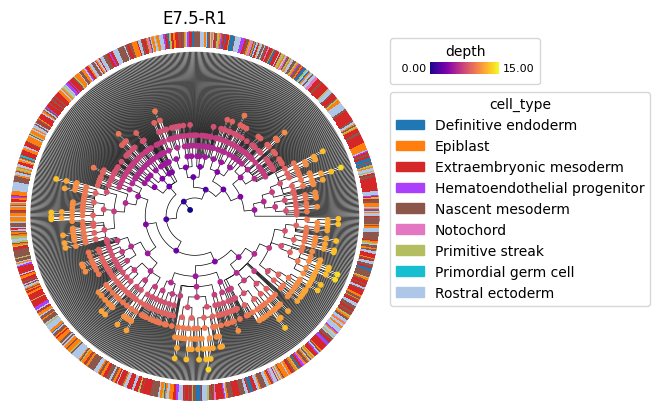

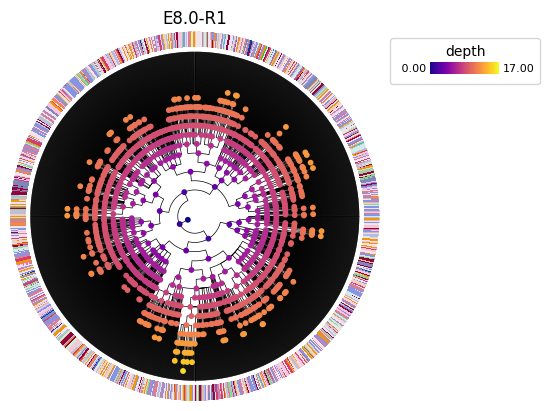

In [36]:
for k, v in tdatas.items():
    py.pp.add_depth(v)
    py.pl.branches(v, polar=True, extend_branches=True, tree=str(k)+"-C1")
    py.pl.nodes(v, color='depth', cmap="plasma")
    py.pl.annotation(v, keys='cell_type', cmap='viridis', width=.1)
    plt.title(k)

In [41]:
v.obs

,cell_subtype,capture,embryo,stage,type,total_counts,pe_counts,detection_rate,edit_frac,clone,phase,cell_type,germ_layer,lineage,tree,depth
E8.0-R1-T1-CTCCCTGGTGAGCGAT-1,Forebrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,19493.0,28.0,0.970588,0.480392,E8.0-R1-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,9.0
E8.0-R1-T1-GTGCGAGGTCAACTCG-1,Forebrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,18041.0,18.0,0.970588,0.480392,E8.0-R1-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,9.0
E8.0-R1-T1-TGGATGCTCATACTCC-1,Forebrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,16307.0,32.0,0.882353,0.559140,E8.0-R1-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,12.0
E8.0-R1-T1-CGCACGATCCGCGTAG-1,Hindbrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,12310.0,17.0,0.882353,0.537634,E8.0-R1-C1,G2/M,Hindbrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,12.0
E8.0-R1-T1-AAGGTTAAGTAACCTG-1,Forebrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,19102.0,31.0,0.941176,0.505051,E8.0-R1-C1,S,Forebrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E8.0-R1-T1-TGGGTGAAGTCAAGCC-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,28256.0,0.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,NaN
E8.0-R1-T1-TGGTCCTCACTCGGAA-1,Gut,E8.0-R1-T1,E8.0-R1,E8.0,donor,10322.0,17.0,0.735294,NaN,NaN,G2/M,Gut,Endoderm,Endoderm,NaN,NaN
E8.0-R1-T1-TGTAGCGCAATCGAGT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,16391.0,0.0,NaN,NaN,NaN,G2/M,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,NaN
E8.0-R1-T1-TGTCGATGTGCAATCT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,21732.0,1.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,NaN
